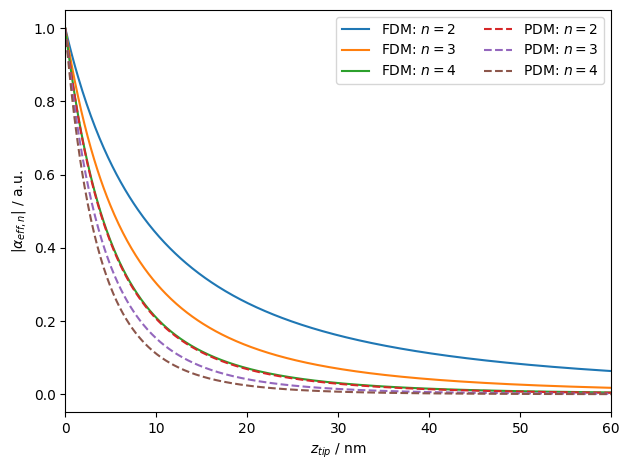

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import snompy

# Set some experimental parameters for an AFM approach curve
z_tip = np.linspace(0, 60e-9, 512)  # Define an approach curve
A_tip = 20e-9  # AFM tip tapping amplitude
harmonics = np.array([2, 3, 4])  # Harmonics for demodulation
eps_Si = 11.7  # Si permitivitty in the mid-infrared
sample = snompy.bulk_sample(eps_sub=eps_Si)  # Sample object

# Calculate the effective polarizability using FDM and PDM
alpha_eff_fdm = snompy.fdm.eff_pol_n(
    sample=sample,
    A_tip=A_tip,
    n=harmonics,
    z_tip=z_tip[:, np.newaxis],  # newaxis added for array broadcasting
)
alpha_eff_pdm = snompy.pdm.eff_pol_n(
    sample=sample,
    A_tip=A_tip,
    n=harmonics,
    z_tip=z_tip[:, np.newaxis],  # newaxis added for array broadcasting
)

# Normalize to value at z_tip = 0
alpha_eff_fdm /= alpha_eff_fdm[0]
alpha_eff_pdm /= alpha_eff_pdm[0]

# Plot output
fig, ax = plt.subplots()
z_nm = z_tip * 1e9  # For neater plotting
ax.plot(z_nm, np.abs(alpha_eff_fdm), label=[f"FDM: $n = ${n}" for n in harmonics])
ax.plot(
    z_nm, np.abs(alpha_eff_pdm), label=[f"PDM: $n = ${n}" for n in harmonics], ls="--"
)
ax.set(
    xlabel=r"$z_{tip}$ / nm",
    ylabel=r"$|\alpha_{eff, n}|$ / a.u.",
    xlim=(z_nm.min(), z_nm.max()),
)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()


Connecting to nano-FTIR instrument...
Sample set to: Si3N4 on Si


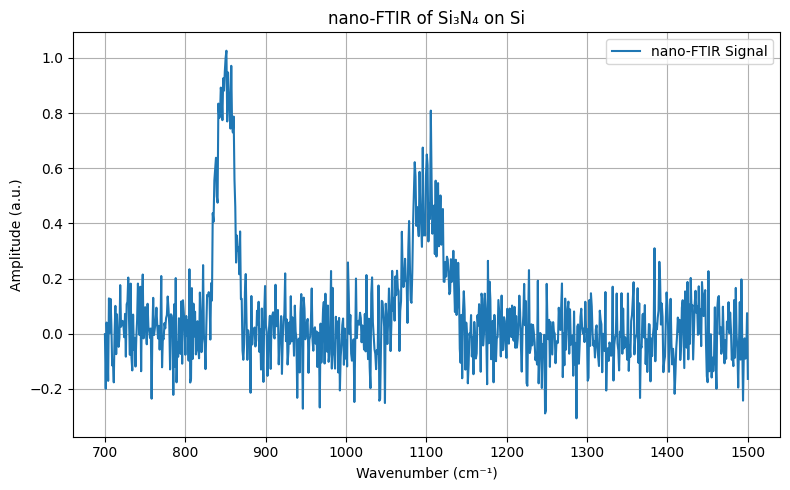

Disconnecting...


In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Assuming snompy is the control library provided by the instrument vendor
# import snompy 

class MockSNOM:
    """Mock class to simulate nano-FTIR signal acquisition."""
    def __init__(self):
        print("Connecting to nano-FTIR instrument...")
        self.connected = True

    def set_sample(self, sample_name):
        print(f"Sample set to: {sample_name}")

    def set_scan_parameters(self, start_wavenumber, end_wavenumber, resolution):
        self.wn_start = start_wavenumber
        self.wn_end = end_wavenumber
        self.resolution = resolution
        self.wns = np.linspace(start_wavenumber, end_wavenumber, resolution)

    def acquire_signal(self):
        """Simulated FTIR signal of Si3N4 on Si (mock spectrum)."""
        # Simulated response: Si3N4 absorption near 850 cm⁻¹ and 1100 cm⁻¹
        signal = (
            np.exp(-((self.wns - 850) ** 2) / (2 * 10**2)) +
            0.5 * np.exp(-((self.wns - 1100) ** 2) / (2 * 20**2)) +
            0.1 * np.random.randn(len(self.wns))
        )
        return self.wns, signal

    def disconnect(self):
        print("Disconnecting...")
        self.connected = False


def main():
    # Initialize instrument
    instrument = MockSNOM()
    instrument.set_sample("Si3N4 on Si")

    # Set FTIR scan range (e.g., mid-IR: 700–1500 cm⁻¹)
    instrument.set_scan_parameters(start_wavenumber=700, end_wavenumber=1500, resolution=800)

    # Acquire signal
    wavenumbers, signal = instrument.acquire_signal()

    # Plot the result
    plt.figure(figsize=(8, 5))
    plt.plot(wavenumbers, signal, label="nano-FTIR Signal")
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Amplitude (a.u.)")
    plt.title("nano-FTIR of Si₃N₄ on Si")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    instrument.disconnect()


if __name__ == "__main__":
    main()


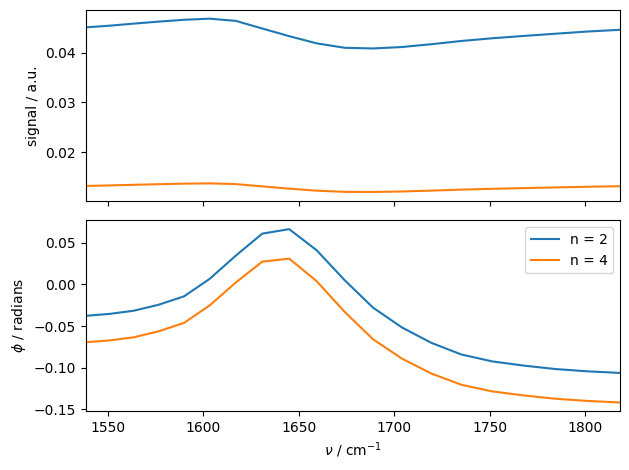

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy


# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)
all_signal = []
all_phase = []
for n in [2,3,4]:
    # Set some experimental parameters
    A_tip = 100e-9  # AFM tip tapping amplitude
    r_tip = 150e-9  # AFM tip radius of curvature
    L_tip = 30000e-9  # Semi-major axis length of ellipsoid tip model
    theta_in = np.deg2rad(60)  # Light angle of incidence
    c_r = 1  # Experimental weighting factor
    nu_vac = 10000 / np.linspace(5.5, 6.5, 20) * 1e2  # Vacuum wavenumber
    method = "Q_ave"  # The FDM method to use

    # Semi-infinite superstrate and substrate
    eps_air = 1

    SN_eps1 = [5.214240758,5.189577913,5.158596071,5.132234122,5.105476174,5.078323095,5.044912859,5.016982676,4.988657899,4.960383558,4.926336716,4.897716309,4.870017466,4.841908539,4.808918896,4.782182184,4.755462076,4.729192562,4.698031228,4.672649601]
    SN_eps2 = [0.052369789,0.0579366392,0.0654543234,0.072514124,0.0803332992,0.088994664,0.1006117904,0.11131008,0.1229785872,0.13564866,0.1522028068,0.1670054568,0.182778232,0.1994103436,0.220372171,0.238590625,0.257386459,0.2766623496,0.3003250768,0.3204249834]
    water_eps1 = [1.68466944,1.67297584,1.6582095039,1.6426922604,1.6264349851,1.6070444736,1.5840760944,1.5651490064,1.5609382144,1.5785945364,1.6284318,1.6954608,1.76080923,1.82452608,1.845517,1.83946575,1.8278883344,1.8149778679,1.8018807975,1.79138436]
    water_eps2 = [0.0301136,0.0333723,0.038144636,0.045785896,0.05502507,0.07080512,0.097814656,0.133835136,0.178099248,0.235752488,0.29262608,0.33018968,0.31466564,0.26163144,0.20572272,0.16318352,0.14114496,0.12431256,0.1129463,0.1049776]

    
    eps_SN = []
    eps_H2O = []
    for i in range(len(nu_vac)):
        eps_SN.append(SN_eps1[i] + SN_eps2[i]*1j)
        eps_H2O.append(water_eps1[i] + water_eps2[i]*1j)
    # eps_SN = 4.9 + 1j*0.14
    # eps_H2O = 1.58 + 1j*0.27

    t = np.array([15]) * 1e-9
    sample_SN = snompy.Sample(
        eps_stack=(eps_air, eps_SN, eps_H2O),
        t_stack=(t[:,np.newaxis],),
        nu_vac=nu_vac,
    )
    eps_Si = 11.6
    sample_ref = snompy.Sample(
        eps_stack=(eps_air, eps_SN, eps_Si),
        t_stack=(t[:,np.newaxis],),
        nu_vac=nu_vac,
    )

    # Model of Au dielectric function from ref [2] below
    eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
    sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)
    eps_Si = 11.6
    sample_Si = snompy.bulk_sample(eps_sub=eps_Si, eps_env=eps_air, nu_vac=nu_vac)

    # Measurement
    alpha_eff_SN = snompy.fdm.eff_pol_n(
        sample=sample_SN, A_tip=A_tip, n=n, z_tip=102e-9, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_SN = sample_SN.refl_coef(theta_in=theta_in)
    sigma_SN = (1 + c_r * r_coef_SN) ** 2 * alpha_eff_SN

    # Silicon reference
    alpha_eff_Si = snompy.fdm.eff_pol_n(
        sample=sample_ref, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Si = sample_ref.refl_coef(theta_in=theta_in)
    sigma_Si = (1 + c_r * r_coef_Si) ** 2 * alpha_eff_Si

    # Normalised complex scattering
    eta_n = sigma_SN/ sigma_Si


    # For neater plotting
    nu_per_cm = nu_vac * 1e-2
    t_nm =  t * 1e9

    # axes[0].plot(nu_per_cm, np.abs(eta_n),label="n = "+str(n))
    # axes[1].plot(nu_per_cm, np.angle(eta_n),label="n = "+str(n))

    for t, sigma in zip(t_nm, eta_n):
        all_signal.append(np.abs(sigma))
        all_phase.append(np.angle(sigma))
        axes[0].plot(nu_per_cm, np.abs(sigma),label="n = "+str(n))
        axes[1].plot(nu_per_cm, np.angle(sigma),label="n = "+str(n))

    axes[0].set_ylabel(r"signal / a.u.")
    axes[1].set(
        xlabel=r"$\nu$ / cm$^{-1}$",
        ylabel=r"$\phi$ / radians",
        xlim=(nu_per_cm.max(), nu_per_cm.min()),
    )
    plt.legend()
# axes[0].plot(nu_per_cm, all_signal[1]/all_signal[2],label="3/1")
# axes[1].plot(nu_per_cm, all_phase[1]/all_phase[2],label="3/1")
plt.gca().invert_xaxis()
fig.tight_layout()
plt.show(block=False)

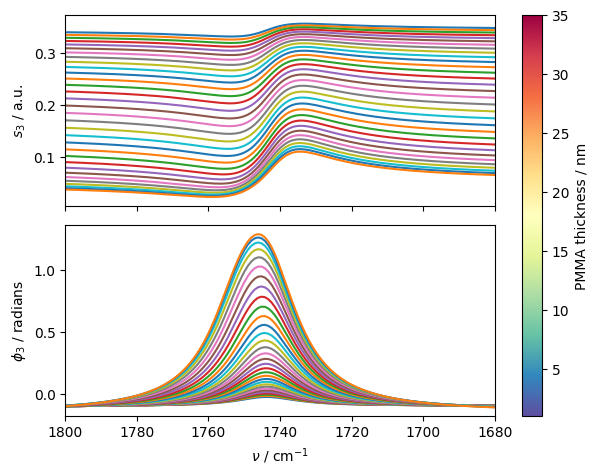

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Set some experimental parameters
A_tip = 20e-9  # AFM tip tapping amplitude
r_tip = 30e-9  # AFM tip radius of curvature
L_tip = 350e-9  # Semi-major axis length of ellipsoid tip model
n = 3  # Harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3  # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"  # The FDM method to use

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_H2O = 1.6  # H2O permitivitty in the mid-infrared

# Very simplified model of PMMA dielectric function based on ref [1] below
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # A range of thicknesses
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Model of Au dielectric function from ref [2] below
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_pmma / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

# For neater plotting
nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)  # This maps thickness to colour

for t, sigma in zip(t_nm, eta_n):
    axes[0].plot(nu_per_cm, np.abs(sigma))
    axes[1].plot(nu_per_cm, np.angle(sigma))

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)

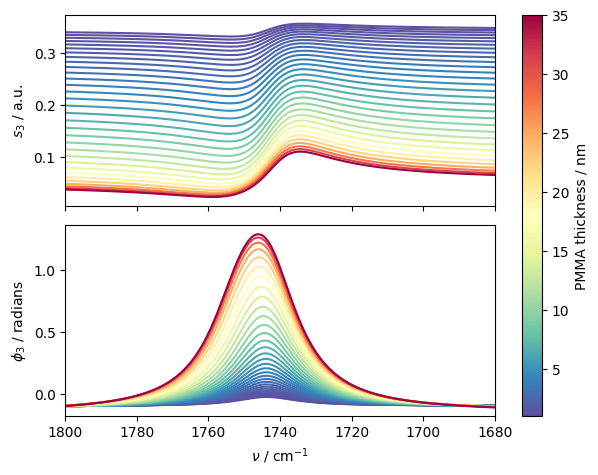

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Set some experimental parameters
A_tip = 20e-9  # AFM tip tapping amplitude
r_tip = 30e-9  # AFM tip radius of curvature
L_tip = 350e-9  # Semi-major axis length of ellipsoid tip model
n = 3  # Harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3  # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"  # The FDM method to use

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_H2O = 1.6  # H2O permitivitty in the mid-infrared

# Very simplified model of SiNx dielectric function
eps_SiNx = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # A range of thicknesses
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Model of Au dielectric function from ref [2] below
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_pmma / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

# For neater plotting
nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)  # This maps thickness to colour

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)

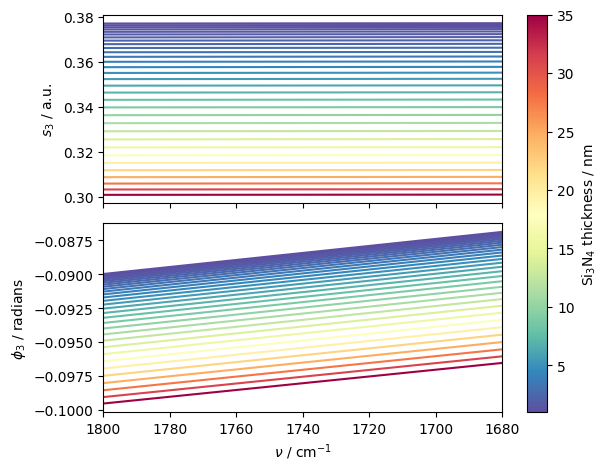

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# Set some experimental parameters
A_tip = 20e-9   # AFM tip tapping amplitude
r_tip = 30e-9   # AFM tip radius of curvature
L_tip = 350e-9  # Semi-major axis length of ellipsoid tip model
n = 3           # Harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3       # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"  # The FDM method to use

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # Si permittivity in the mid-infrared

# Silicon nitride dielectric function (constant for mid-IR)
eps_si3n4 = np.full_like(nu_vac, 7.5)  # Real permittivity (n~2.74, k~0)
t_si3n4 = np.geomspace(1, 35, 32) * 1e-9  # A range of thicknesses
sample_si3n4 = snompy.Sample(
    eps_stack=(eps_air, eps_si3n4, eps_Si),
    t_stack=(t_si3n4[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement for Si3N4
alpha_eff_si3n4 = snompy.fdm.eff_pol_n(
    sample=sample_si3n4, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_si3n4 = sample_si3n4.refl_coef(theta_in=theta_in)
sigma_si3n4 = (1 + c_r * r_coef_si3n4) ** 2 * alpha_eff_si3n4

# Measurement for gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_si3n4 / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
t_nm = t_si3n4 * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="Si$_3$N$_4$ thickness / nm")
plt.show(block=False)


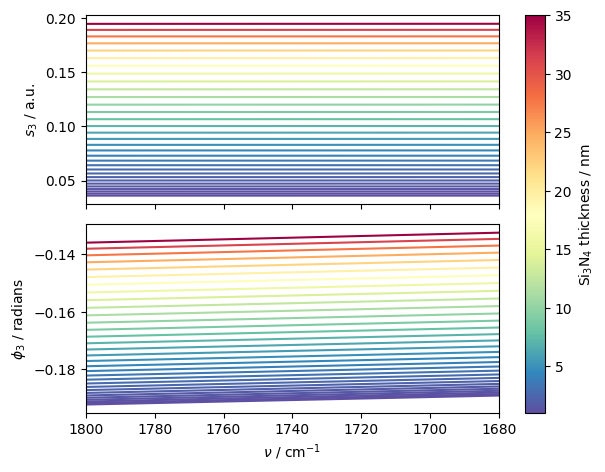

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 3
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # m⁻¹
method = "Q_ave"

# Permittivity of air
eps_air = 1.0

# Approximate permittivity of water in MIR (constant here for simplicity)
n_water = 1.25
k_water = 0.001
eps_water = (n_water + 1j * k_water) ** 2  # complex permittivity

# Si3N4 layer permittivity (constant)
eps_si3n4 = np.full_like(nu_vac, 7.5)

# Si3N4 thicknesses
t_si3n4 = np.geomspace(1, 35, 32) * 1e-9

# Create sample: air / Si3N4 / water
sample_si3n4_water = snompy.Sample(
    eps_stack=(eps_air, eps_si3n4, eps_water),
    t_stack=(t_si3n4[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Gold reference sample
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement for Si3N4 on water
alpha_eff = snompy.fdm.eff_pol_n(
    sample=sample_si3n4_water, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef = sample_si3n4_water.refl_coef(theta_in=theta_in)
sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

# Measurement for gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalized scattering
eta_n = sigma / sigma_Au

# Plotting
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
t_nm = t_si3n4 * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma_val in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma_val), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma_val), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="Si$_3$N$_4$ thickness / nm")
plt.show(block=False)


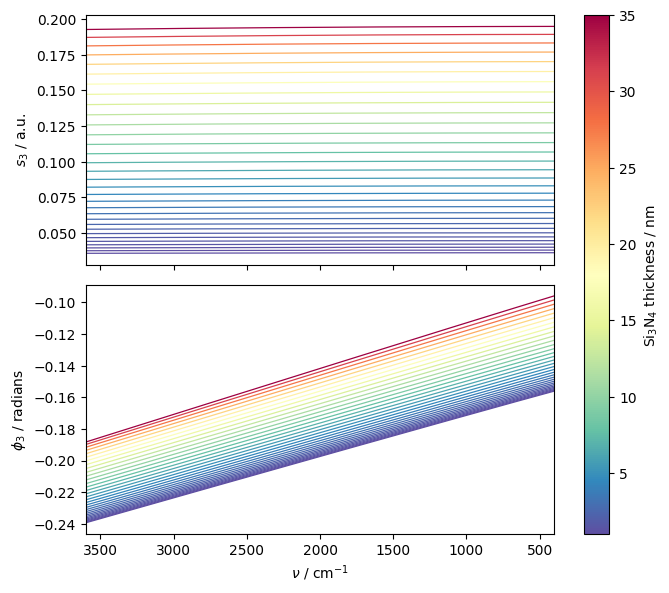

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# Set experimental parameters (unchanged)
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 3
theta_in = np.deg2rad(60)
c_r = 0.3

# --- IMPORTANT: updated spectral window to include Si3N4 and water absorption regions ---
nu_vac = np.linspace(400, 3600, 1024) * 1e2  # 400–3600 cm^-1 -> converted to m^-1

method = "Q_ave"

# Layers
eps_air = 1.0

# Quick Si3N4 approx (keep or replace with dataset later)
eps_si3n4 = np.full_like(nu_vac, 7.5)  # ~n=2.74, approximate, no dispersion in this simple model

# Quick water approx (simple constant complex refractive index)
n_water = 1.25
k_water = 0.001
eps_water = (n_water + 1j * k_water) ** 2  # constant complex permittivity (approx)

# Thickness sweep for Si3N4
t_si3n4 = np.geomspace(1, 35, 32) * 1e-9

# Build sample: air / Si3N4 / water
sample_si3n4_water = snompy.Sample(
    eps_stack=(eps_air, eps_si3n4, eps_water),
    t_stack=(t_si3n4[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Gold reference (unchanged)
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Simulate
alpha_eff = snompy.fdm.eff_pol_n(
    sample=sample_si3n4_water, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef = sample_si3n4_water.refl_coef(theta_in=theta_in)
sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalized scattering
eta_n = sigma / sigma_Au

# Plotting
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(7,6))
nu_per_cm = nu_vac * 1e-2
t_nm = t_si3n4 * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma_val in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma_val), c=c, lw=0.9)
    axes[1].plot(nu_per_cm, np.angle(sigma_val), c=c, lw=0.9)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="Si$_3$N$_4$ thickness / nm")
plt.show(block=False)


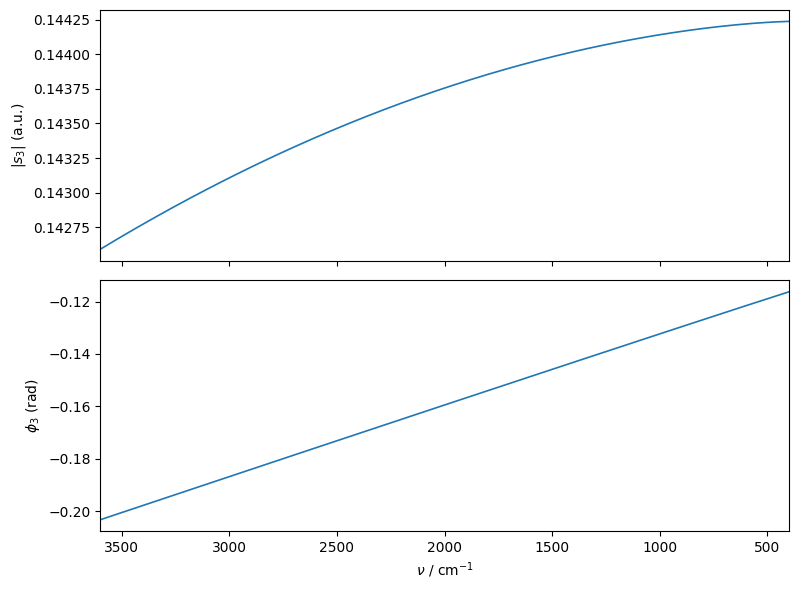

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# ----- experimental parameters -----
A_tip = 20e-9      # tip tapping amplitude
r_tip = 30e-9      # tip radius
L_tip = 350e-9     # ellipsoid semi-major axis
n = 3              # harmonic order
theta_in = np.deg2rad(60)
c_r = 0.3
method = "Q_ave"

# ----- spectral window (400 - 3600 cm^-1) -----
nu_vac = np.linspace(400, 3600, 1024) * 1e2  # convert cm^-1 -> m^-1

# ----- layers -----
eps_air = 1.0
# simple (non-dispersive) Si3N4 approximation
eps_si3n4 = np.full_like(nu_vac, 7.5)

# quick water approximation (complex, non-dispersive)
n_water = 1.2180
k_water = 0.0050800
eps_water = (n_water + 1j * k_water) ** 2

# ----- fixed Si3N4 thickness: 15 nm -----
t_si3n4 = np.array([15e-9])          # single thickness, shape (1,)
# snompy expects t_stack shape like (n_thicknesses, 1) -> use [:, np.newaxis]
sample = snompy.Sample(
    eps_stack=(eps_air, eps_si3n4, eps_water),
    t_stack=(t_si3n4[:, np.newaxis],),
    nu_vac=nu_vac,
)

# ----- gold reference -----
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# ----- simulate Si3N4-on-water -----
alpha_eff = snompy.fdm.eff_pol_n(
    sample=sample, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef = sample.refl_coef(theta_in=theta_in)
sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

# ----- simulate gold reference -----
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# ----- normalized scattering -----
eta_n = sigma / sigma_Au   # shape: (1, n_freq) if snompy keeps thickness axis first

# ----- plotting -----
nu_per_cm = nu_vac * 1e-2

fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,6))
# eta_n may be (1, N) or (N,), safe indexing:
spec = eta_n[0] if eta_n.ndim == 2 else eta_n

axes[0].plot(nu_per_cm, np.abs(spec), lw=1.2)
axes[0].set_ylabel(r"$|s_{" f"{n}" r"}|$ (a.u.)")

axes[1].plot(nu_per_cm, np.angle(spec), lw=1.2)
axes[1].set_ylabel(r"$\phi_{" f"{n}" r"}$ (rad)")
axes[1].set_xlabel(r"$\nu$ / cm$^{-1}$")
axes[1].set_xlim(nu_per_cm.max(), nu_per_cm.min())  # reverse x axis (high -> low)

fig.tight_layout()
plt.show(block=False)


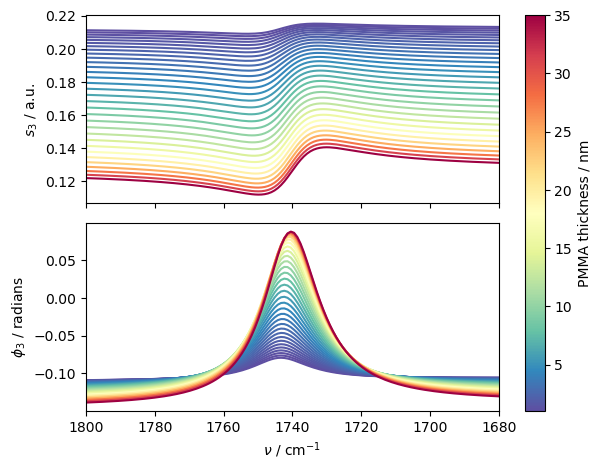

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 3
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # mid-IR permittivity of Si

# Si3N4 dielectric function (Lorentz-like model for mid-IR absorption)
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac,
    nu_j=900e2,      # main absorption peak ~11 µm
    gamma_j=50e2,    # damping
    A_j=2e8,         # strength
    eps_inf=4.0      # high-frequency permittivity
)

t_Si3N4 = 15e-9  # fixed thickness of Si3N4

# PMMA dielectric function (simplified model)
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9

# Define the 4-layer stack: air / Si3N4 / PMMA / Si
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_Si3N4)[:, np.newaxis],
             t_pmma[:, np.newaxis]),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_stack / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)


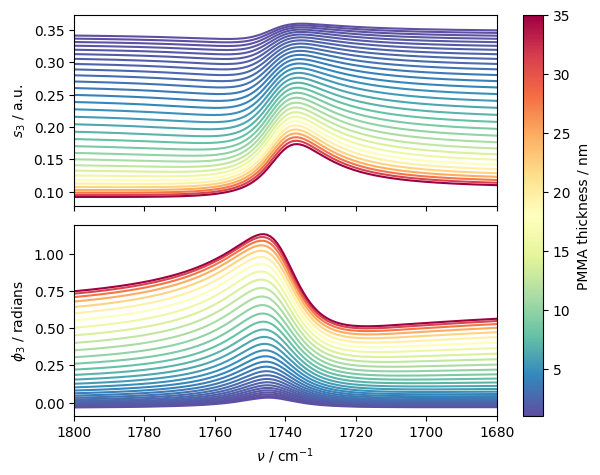

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 3
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1] as in your original code (cm^-1 * 1e2)
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7  # approximate mid-IR permittivity of Si

# -------------------------------------------------------
# PMMA dielectric function (same synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # 1–35 nm

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
# Constants
eps0 = 8.8541878128e-12  # F/m
c0   = 299792458.0       # m/s
e    = 1.602176634e-19   # C
hbar = 1.054571817e-34   # J*s

sigma0 = e**2 / (4*hbar)   # ~6.085e-5 S (universal interband sheet conductivity)
t_g = 0.3e-9               # 0.3 nm monolayer thickness

# Angular frequency omega = 2π * c * k0, with k0 = nu_vac [m^-1]
omega = 2*np.pi * c0 * (nu_vac * 1.0)  # [rad/s]

# Effective bulk permittivity for ultra-thin film:
# eps_g(ω) = 1 + i * sigma_sheet / (eps0 * ω * t_g)
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------------------------------
# Build 4-layer sample: air / graphene / PMMA / Si
# -------------------------------------------------------
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],   # fixed graphene thickness
             t_pmma[:, np.newaxis]),                     # varying PMMA thickness
    nu_vac=nu_vac,
)

# --------------------
# Gold reference (Au)
# --------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# --------------------
# Measurement signals
# --------------------
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# -------------------------------
# Normalized complex scattering
# -------------------------------
eta_n = sigma_stack / sigma_Au

# -----------
# Plotting
# -----------
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2        # for axis labeling (cm^-1)
t_nm = t_pmma * 1e9              # PMMA thickness in nm

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)


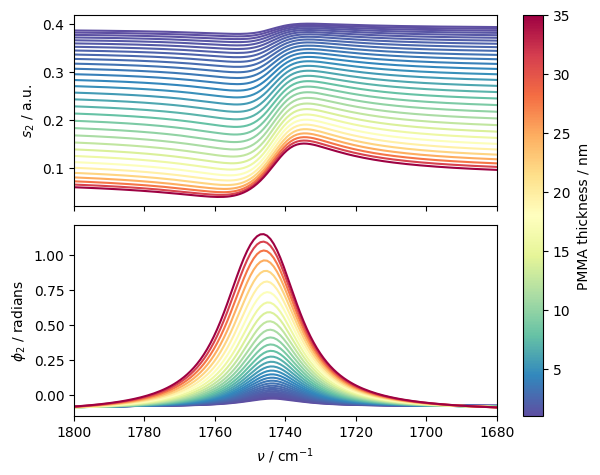

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Set some experimental parameters
A_tip = 20e-9  # AFM tip tapping amplitude
r_tip = 30e-9  # AFM tip radius of curvature
L_tip = 350e-9  # Semi-major axis length of ellipsoid tip model
n = 2  # Harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3  # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"  # The FDM method to use

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # Si permitivitty in the mid-infrared

# Very simplified model of PMMA dielectric function based on ref [1] below
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # A range of thicknesses
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Model of Au dielectric function from ref [2] below
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_pmma / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

# For neater plotting
nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)  # This maps thickness to colour

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)

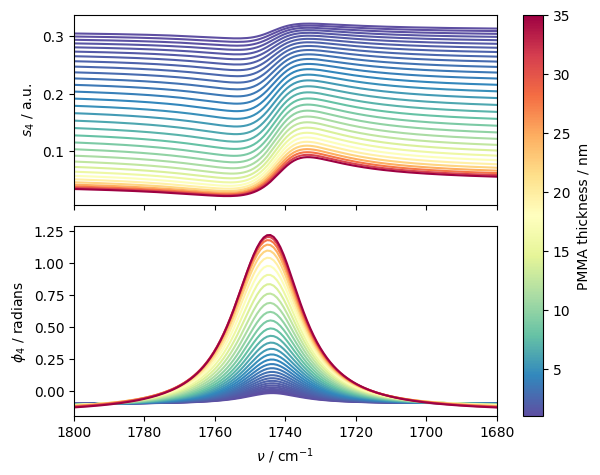

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Set some experimental parameters
A_tip = 20e-9  # AFM tip tapping amplitude
r_tip = 30e-9  # AFM tip radius of curvature
L_tip = 350e-9  # Semi-major axis length of ellipsoid tip model
n = 4  # Harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3  # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"  # The FDM method to use

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # Si permitivitty in the mid-infrared

# Very simplified model of PMMA dielectric function based on ref [1] below
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # A range of thicknesses
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Model of Au dielectric function from ref [2] below
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_pmma / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

# For neater plotting
nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)  # This maps thickness to colour

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)

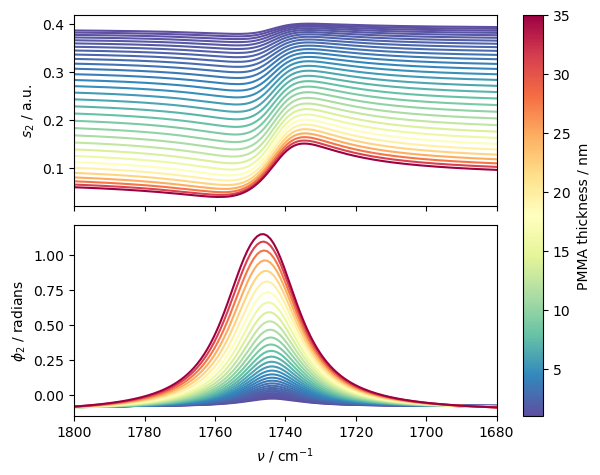

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Set some experimental parameters
A_tip = 20e-9  # AFM tip tapping amplitude
r_tip = 30e-9  # AFM tip radius of curvature
L_tip = 350e-9  # Semi-major axis length of ellipsoid tip model
n = 2  # Harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3  # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"  # The FDM method to use

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # Si permitivitty in the mid-infrared

# Very simplified model of PMMA dielectric function based on ref [1] below
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # A range of thicknesses
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac,
)

# Model of Au dielectric function from ref [2] below
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_pmma / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

# For neater plotting
nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)  # This maps thickness to colour

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
cbar = fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)

In [ ]:
## Fixed thickness of PMMA 30 nm (Order 2 demodulation for the original simulation)

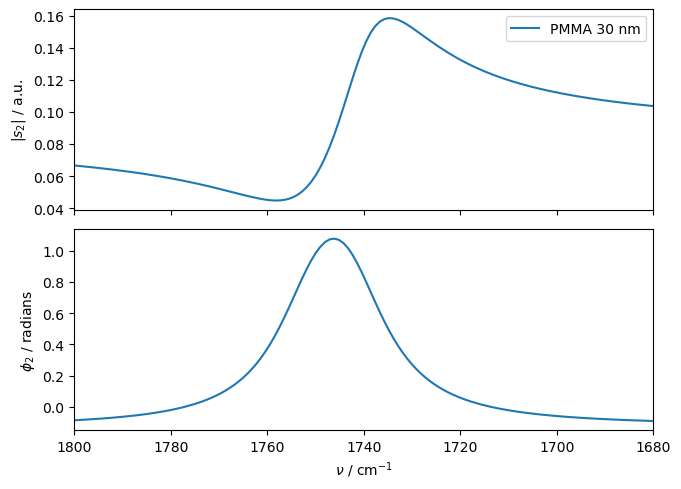

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# ----------------------------
# Experimental parameters
# ----------------------------
A_tip = 20e-9       # AFM tip tapping amplitude
r_tip = 30e-9       # AFM tip radius of curvature
L_tip = 350e-9      # Semi-major axis length of ellipsoid tip model
n = 2               # 2nd harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3           # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"    # FDM method

# ----------------------------
# Dielectric constants
# ----------------------------
eps_air = 1.0
eps_Si = 11.7  # Si permitivitty in the mid-infrared

# PMMA (fixed 30 nm)
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed thickness
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(np.array([t_pmma])[:, np.newaxis],),
    nu_vac=nu_vac
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# ----------------------------
# Measurement
# ----------------------------
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalized complex scattering
eta_n = sigma_pmma / sigma_Au

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(7,5))
nu_per_cm = nu_vac * 1e-2

axes[0].plot(nu_per_cm, np.abs(eta_n[0]), label=f"PMMA {t_pmma*1e9:.0f} nm")
axes[1].plot(nu_per_cm, np.angle(eta_n[0]), label=f"PMMA {t_pmma*1e9:.0f} nm")

axes[0].set_ylabel(r"$|s_{" f"{n}" r"}|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)

axes[0].legend()
fig.tight_layout()
plt.show()


In [ ]:
## Fixed thickness of PMMA 30 nm (Order 3 demodulation for the original simulation)

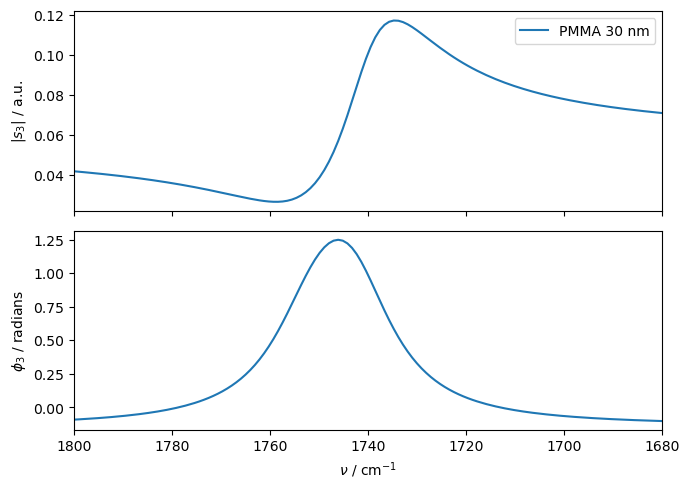

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# ----------------------------
# Experimental parameters
# ----------------------------
A_tip = 20e-9       # AFM tip tapping amplitude
r_tip = 30e-9       # AFM tip radius of curvature
L_tip = 350e-9      # Semi-major axis length of ellipsoid tip model
n = 3               # 2nd harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3           # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"    # FDM method

# ----------------------------
# Dielectric constants
# ----------------------------
eps_air = 1.0
eps_Si = 11.7  # Si permitivitty in the mid-infrared

# PMMA (fixed 30 nm)
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed thickness
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(np.array([t_pmma])[:, np.newaxis],),
    nu_vac=nu_vac
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# ----------------------------
# Measurement
# ----------------------------
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalized complex scattering
eta_n = sigma_pmma / sigma_Au

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(7,5))
nu_per_cm = nu_vac * 1e-2

axes[0].plot(nu_per_cm, np.abs(eta_n[0]), label=f"PMMA {t_pmma*1e9:.0f} nm")
axes[1].plot(nu_per_cm, np.angle(eta_n[0]), label=f"PMMA {t_pmma*1e9:.0f} nm")

axes[0].set_ylabel(r"$|s_{" f"{n}" r"}|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)

axes[0].legend()
fig.tight_layout()
plt.show()


In [ ]:
## Fixed thickness of PMMA 30 nm (Order 4 demodulation for the original simulation)

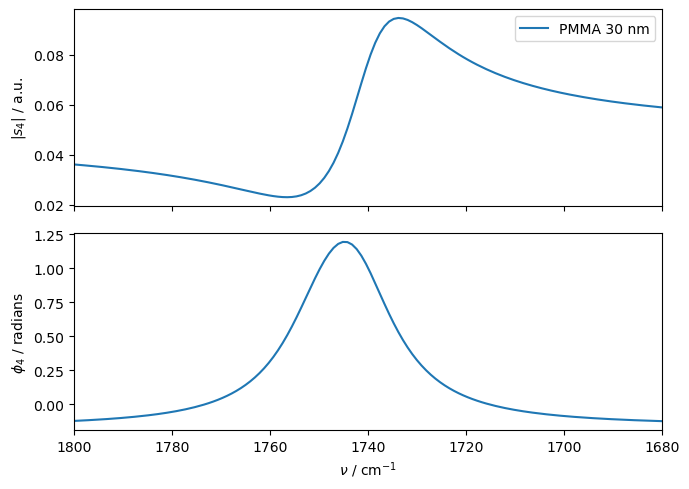

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# ----------------------------
# Experimental parameters
# ----------------------------
A_tip = 20e-9       # AFM tip tapping amplitude
r_tip = 30e-9       # AFM tip radius of curvature
L_tip = 350e-9      # Semi-major axis length of ellipsoid tip model
n = 4               # 2nd harmonic for demodulation
theta_in = np.deg2rad(60)  # Light angle of incidence
c_r = 0.3           # Experimental weighting factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Vacuum wavenumber
method = "Q_ave"    # FDM method

# ----------------------------
# Dielectric constants
# ----------------------------
eps_air = 1.0
eps_Si = 11.7  # Si permitivitty in the mid-infrared

# PMMA (fixed 30 nm)
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed thickness
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(np.array([t_pmma])[:, np.newaxis],),
    nu_vac=nu_vac
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# ----------------------------
# Measurement
# ----------------------------
alpha_eff_pmma = snompy.fdm.eff_pol_n(
    sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_pmma = sample_pmma.refl_coef(theta_in=theta_in)
sigma_pmma = (1 + c_r * r_coef_pmma) ** 2 * alpha_eff_pmma

# Gold reference
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalized complex scattering
eta_n = sigma_pmma / sigma_Au

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(7,5))
nu_per_cm = nu_vac * 1e-2

axes[0].plot(nu_per_cm, np.abs(eta_n[0]), label=f"PMMA {t_pmma*1e9:.0f} nm")
axes[1].plot(nu_per_cm, np.angle(eta_n[0]), label=f"PMMA {t_pmma*1e9:.0f} nm")

axes[0].set_ylabel(r"$|s_{" f"{n}" r"}|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)

axes[0].legend()
fig.tight_layout()
plt.show()


In [ ]:
## Combines graphs n=2,3,4

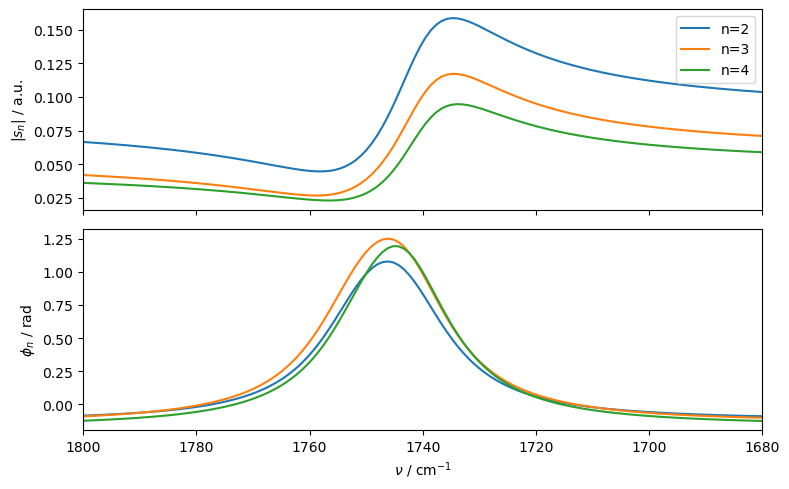

Figure saved at: C:\Users\user\OneDrive\Desktop\Snompy\PMMA_demodulation_orders.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snompy
import os

# ----------------------------
# Folder to save figure
# ----------------------------
save_folder = r"C:\Users\user\OneDrive\Desktop\Snompy"  # Windows path as raw string
os.makedirs(save_folder, exist_ok=True)  # create folder if it doesn't exist
save_path = os.path.join(save_folder, "PMMA_demodulation_orders.png")

# ----------------------------
# Experimental parameters
# ----------------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# ----------------------------
# Dielectric constants
# ----------------------------
eps_air = 1.0
eps_Si = 11.7

eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9
sample_pmma = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(np.array([t_pmma])[:, np.newaxis],),
    nu_vac=nu_vac
)

eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# ----------------------------
# Demodulation orders
# ----------------------------
demod_orders = [2, 3, 4]
eta_list = []

for n in demod_orders:
    alpha_eff = snompy.fdm.eff_pol_n(
        sample=sample_pmma, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef = sample_pmma.refl_coef(theta_in=theta_in)
    sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

    alpha_eff_Au = snompy.fdm.eff_pol_n(
        sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
    sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

    eta_list.append(sigma / sigma_Au)

# ----------------------------
# Plot
# ----------------------------
nu_per_cm = nu_vac * 1e-2
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,5))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for eta, n, c in zip(eta_list, demod_orders, colors):
    axes[0].plot(nu_per_cm, np.abs(eta[0]), label=f"n={n}", color=c)
    axes[1].plot(nu_per_cm, np.angle(eta[0]), label=f"n={n}", color=c)

axes[0].set_ylabel(r"$|s_n|$ / a.u.")
axes[1].set_ylabel(r"$\phi_n$ / rad")
axes[1].set_xlabel(r"$\nu$ / cm$^{-1}$")
axes[1].set_xlim(nu_per_cm.max(), nu_per_cm.min())
axes[0].legend()
fig.tight_layout()

# ----------------------------
# Save to specific folder
# ----------------------------
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved at: {save_path}")


In [ ]:
## Order 2 demodulation for Si3N4 

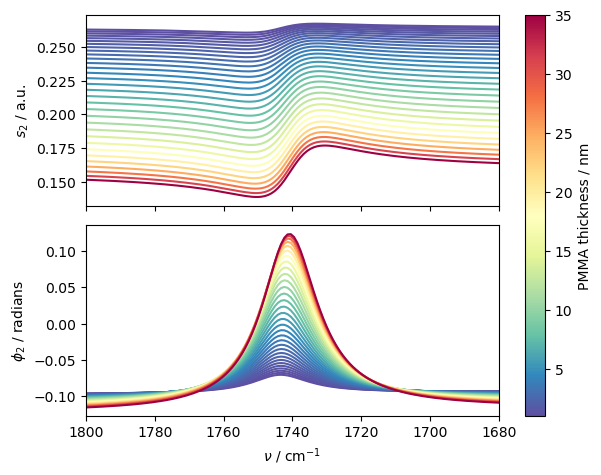

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 2
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # mid-IR permittivity of Si

# Si3N4 dielectric function (Lorentz-like model for mid-IR absorption)
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac,
    nu_j=900e2,      # main absorption peak ~11 µm
    gamma_j=50e2,    # damping
    A_j=2e8,         # strength
    eps_inf=4.0      # high-frequency permittivity
)

t_Si3N4 = 15e-9  # fixed thickness of Si3N4

# PMMA dielectric function (simplified model)
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9

# Define the 4-layer stack: air / Si3N4 / PMMA / Si
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_Si3N4)[:, np.newaxis],
             t_pmma[:, np.newaxis]),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_stack / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)


In [ ]:
## Order 4 demodulation for Si3N4

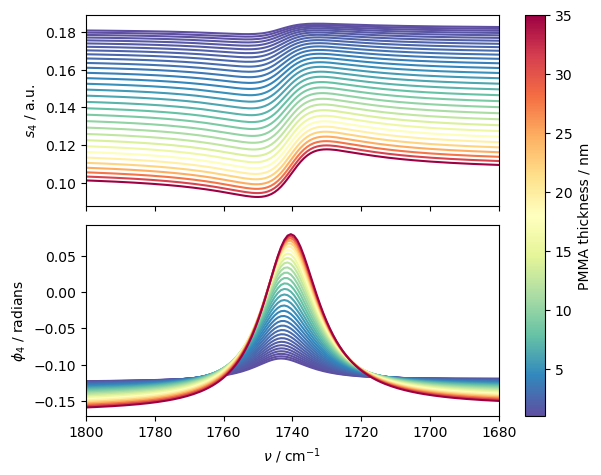

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 4
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # mid-IR permittivity of Si

# Si3N4 dielectric function (Lorentz-like model for mid-IR absorption)
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac,
    nu_j=900e2,      # main absorption peak ~11 µm
    gamma_j=50e2,    # damping
    A_j=2e8,         # strength
    eps_inf=4.0      # high-frequency permittivity
)

t_Si3N4 = 15e-9  # fixed thickness of Si3N4

# PMMA dielectric function (simplified model)
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9

# Define the 4-layer stack: air / Si3N4 / PMMA / Si
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_Si3N4)[:, np.newaxis],
             t_pmma[:, np.newaxis]),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_stack / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
t_nm = t_pmma * 1e9

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)


In [ ]:
## Fixed thickness of PMMA 30 nm (Order 4 demodulation for Si3N4)

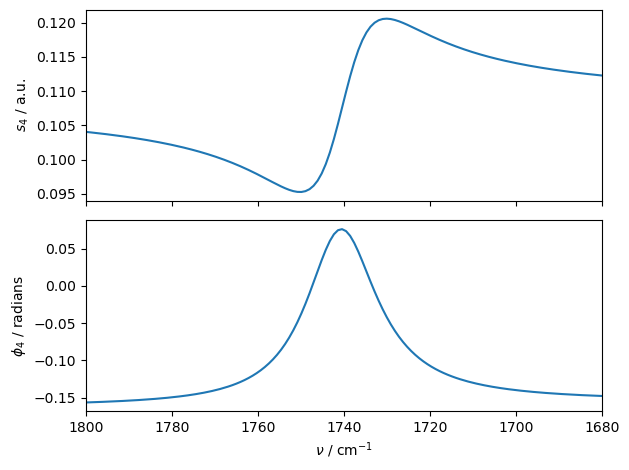

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 4
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # mid-IR permittivity of Si

# Si3N4 dielectric function
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac,
    nu_j=900e2,
    gamma_j=50e2,
    A_j=2e8,
    eps_inf=4.0
)

t_Si3N4 = 15e-9  # fixed thickness of Si3N4

# PMMA dielectric function
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed PMMA thickness

# Define the 4-layer stack: air / Si3N4 / PMMA / Si
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(t_Si3N4, t_pmma),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement for stack
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

# Measurement for gold
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_stack / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
c = 'tab:blue'  # single color

axes[0].plot(nu_per_cm, np.abs(eta_n), color=c)
axes[1].plot(nu_per_cm, np.angle(eta_n), color=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
plt.show(block=False)



In [ ]:
## Fixed thickness of PMMA 30 nm (Order 3 demodulation for Si3N4)

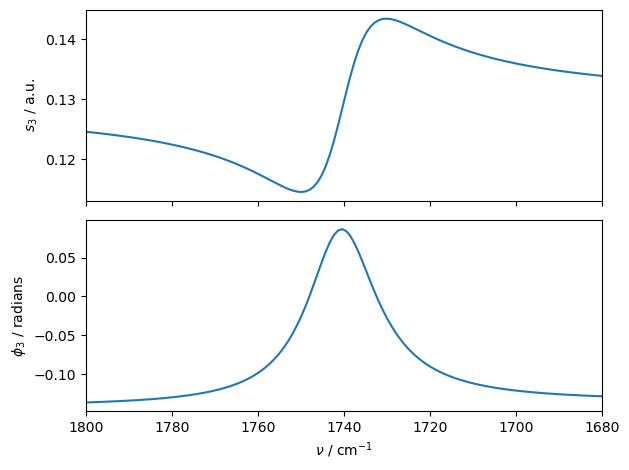

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 3
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # mid-IR permittivity of Si

# Si3N4 dielectric function
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac,
    nu_j=900e2,
    gamma_j=50e2,
    A_j=2e8,
    eps_inf=4.0
)

t_Si3N4 = 15e-9  # fixed thickness of Si3N4

# PMMA dielectric function
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed PMMA thickness

# Define the 4-layer stack: air / Si3N4 / PMMA / Si
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(t_Si3N4, t_pmma),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement for stack
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

# Measurement for gold
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_stack / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
c = 'tab:blue'  # single color

axes[0].plot(nu_per_cm, np.abs(eta_n), color=c)
axes[1].plot(nu_per_cm, np.angle(eta_n), color=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
plt.show(block=False)


In [ ]:
## Fixed thickness of PMMA 30 nm (Order 2 demodulation for Si3N4)

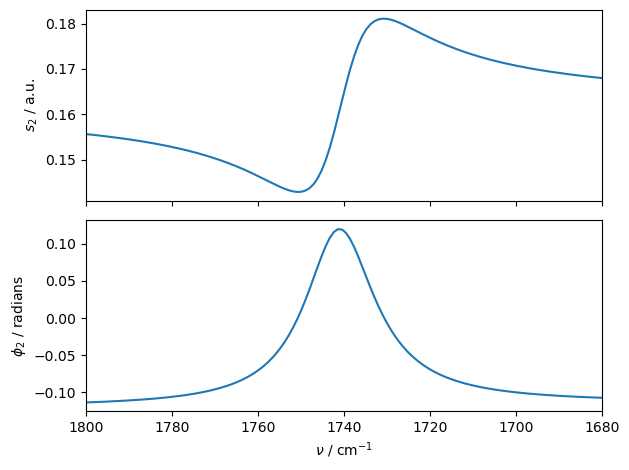

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import snompy

# Experimental parameters
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 2
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2
method = "Q_ave"

# Semi-infinite superstrate and substrate
eps_air = 1.0
eps_Si = 11.7  # mid-IR permittivity of Si

# Si3N4 dielectric function
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac,
    nu_j=900e2,
    gamma_j=50e2,
    A_j=2e8,
    eps_inf=4.0
)

t_Si3N4 = 15e-9  # fixed thickness of Si3N4

# PMMA dielectric function
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed PMMA thickness

# Define the 4-layer stack: air / Si3N4 / PMMA / Si
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(t_Si3N4, t_pmma),
    nu_vac=nu_vac,
)

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# Measurement for stack
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

# Measurement for gold
alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# Normalised complex scattering
eta_n = sigma_stack / sigma_Au

# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2
c = 'tab:blue'  # single color

axes[0].plot(nu_per_cm, np.abs(eta_n), color=c)
axes[1].plot(nu_per_cm, np.angle(eta_n), color=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
plt.show(block=False)


In [ ]:
## Combined code for n=2,3,4 for Si3n4

Figure saved at: C:\Users\user\OneDrive\Desktop\Snompy\demod_comparison.png


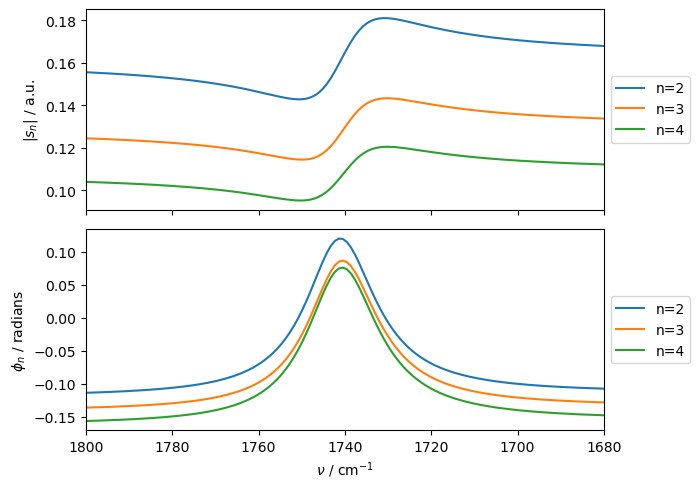

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snompy

# ----------------------------
# Common Experimental Parameters
# ----------------------------
A_tip = 20e-9       # AFM tip tapping amplitude
r_tip = 30e-9       # Tip radius
L_tip = 350e-9      # Ellipsoid tip semi-major axis
theta_in = np.deg2rad(60)  # Incidence angle
c_r = 0.3           # Coupling factor
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # Wavenumber in m^-1
method = "Q_ave"    # FDM method

# ----------------------------
# Dielectric constants
# ----------------------------
eps_air = 1.0
eps_Si = 11.7  # Mid-IR Si
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac, nu_j=900e2, gamma_j=50e2, A_j=2e8, eps_inf=4.0
)
t_Si3N4 = 15e-9

eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = 30e-9  # fixed thickness

# Gold reference
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# ----------------------------
# Demodulation orders to compare
# ----------------------------
demod_orders = [2, 3, 4]
eta_list = []

for n in demod_orders:
    # Build sample stack: air / Si3N4 / PMMA / Si
    sample_stack = snompy.Sample(
        eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
        t_stack=(t_Si3N4, t_pmma),
        nu_vac=nu_vac,
    )

    # Measurement for stack
    alpha_eff_stack = snompy.fdm.eff_pol_n(
        sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
    sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

    # Measurement for gold
    alpha_eff_Au = snompy.fdm.eff_pol_n(
        sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
    sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

    # Normalized complex scattering
    eta_n = sigma_stack / sigma_Au
    eta_list.append(eta_n)

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,5))
nu_per_cm = nu_vac * 1e-2

colors = ['tab:blue', 'tab:orange', 'tab:green']

for eta, n, c in zip(eta_list, demod_orders, colors):
    axes[0].plot(nu_per_cm, np.abs(eta), label=f"n={n}", color=c)
    axes[1].plot(nu_per_cm, np.angle(eta), label=f"n={n}", color=c)

axes[0].set_ylabel(r"$|s_n|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_n$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)

# Move legend to the right outside the plot
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
fig.subplots_adjust(right=0.75)  # make room on the right for legend

# Save figure
save_path = r"C:\Users\user\OneDrive\Desktop\Snompy\demod_comparison.png"
fig.savefig(save_path, dpi=300)
print(f"Figure saved at: {save_path}")

plt.show()



In [ ]:
## Order 2 demodulation for Graphene

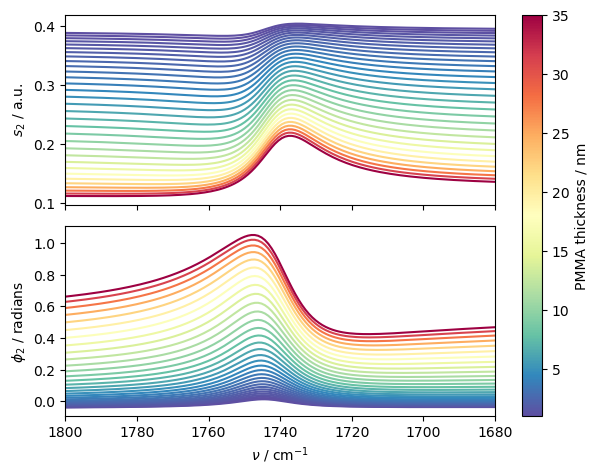

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 2
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1] as in your original code (cm^-1 * 1e2)
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7  # approximate mid-IR permittivity of Si

# -------------------------------------------------------
# PMMA dielectric function (same synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # 1–35 nm

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
# Constants
eps0 = 8.8541878128e-12  # F/m
c0   = 299792458.0       # m/s
e    = 1.602176634e-19   # C
hbar = 1.054571817e-34   # J*s

sigma0 = e**2 / (4*hbar)   # ~6.085e-5 S (universal interband sheet conductivity)
t_g = 0.3e-9               # 0.3 nm monolayer thickness

# Angular frequency omega = 2π * c * k0, with k0 = nu_vac [m^-1]
omega = 2*np.pi * c0 * (nu_vac * 1.0)  # [rad/s]

# Effective bulk permittivity for ultra-thin film:
# eps_g(ω) = 1 + i * sigma_sheet / (eps0 * ω * t_g)
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------------------------------
# Build 4-layer sample: air / graphene / PMMA / Si
# -------------------------------------------------------
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],   # fixed graphene thickness
             t_pmma[:, np.newaxis]),                     # varying PMMA thickness
    nu_vac=nu_vac,
)

# --------------------
# Gold reference (Au)
# --------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# --------------------
# Measurement signals
# --------------------
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# -------------------------------
# Normalized complex scattering
# -------------------------------
eta_n = sigma_stack / sigma_Au

# -----------
# Plotting
# -----------
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2        # for axis labeling (cm^-1)
t_nm = t_pmma * 1e9              # PMMA thickness in nm

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)


In [ ]:
## Order 4 demodulation for Graphene

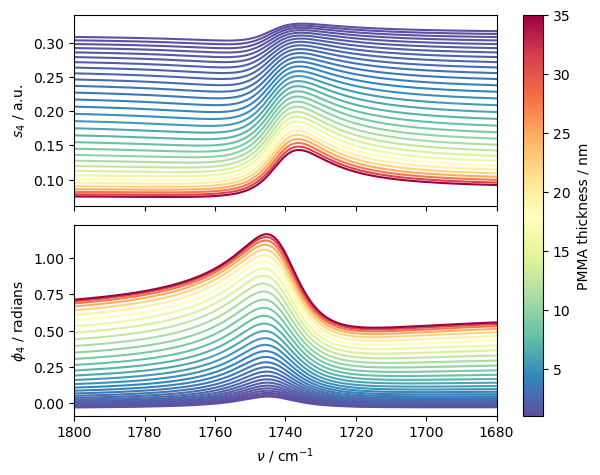

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 4
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1] as in your original code (cm^-1 * 1e2)
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7  # approximate mid-IR permittivity of Si

# -------------------------------------------------------
# PMMA dielectric function (same synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.geomspace(1, 35, 32) * 1e-9  # 1–35 nm

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
# Constants
eps0 = 8.8541878128e-12  # F/m
c0   = 299792458.0       # m/s
e    = 1.602176634e-19   # C
hbar = 1.054571817e-34   # J*s

sigma0 = e**2 / (4*hbar)   # ~6.085e-5 S (universal interband sheet conductivity)
t_g = 0.3e-9               # 0.3 nm monolayer thickness

# Angular frequency omega = 2π * c * k0, with k0 = nu_vac [m^-1]
omega = 2*np.pi * c0 * (nu_vac * 1.0)  # [rad/s]

# Effective bulk permittivity for ultra-thin film:
# eps_g(ω) = 1 + i * sigma_sheet / (eps0 * ω * t_g)
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------------------------------
# Build 4-layer sample: air / graphene / PMMA / Si
# -------------------------------------------------------
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],   # fixed graphene thickness
             t_pmma[:, np.newaxis]),                     # varying PMMA thickness
    nu_vac=nu_vac,
)

# --------------------
# Gold reference (Au)
# --------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# --------------------
# Measurement signals
# --------------------
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# -------------------------------
# Normalized complex scattering
# -------------------------------
eta_n = sigma_stack / sigma_Au

# -----------
# Plotting
# -----------
fig, axes = plt.subplots(nrows=2, sharex=True)

nu_per_cm = nu_vac * 1e-2        # for axis labeling (cm^-1)
t_nm = t_pmma * 1e9              # PMMA thickness in nm

SM = plt.cm.ScalarMappable(
    cmap=plt.cm.Spectral_r, norm=Normalize(vmin=t_nm.min(), vmax=t_nm.max())
)

for t, sigma in zip(t_nm, eta_n):
    c = SM.to_rgba(t)
    axes[0].plot(nu_per_cm, np.abs(sigma), c=c)
    axes[1].plot(nu_per_cm, np.angle(sigma), c=c)

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
fig.colorbar(SM, ax=axes, label="PMMA thickness / nm")
plt.show(block=False)


In [ ]:
## Fixed thickness of PMMA 30 nm (## Order 4 demodulation for Graphene)

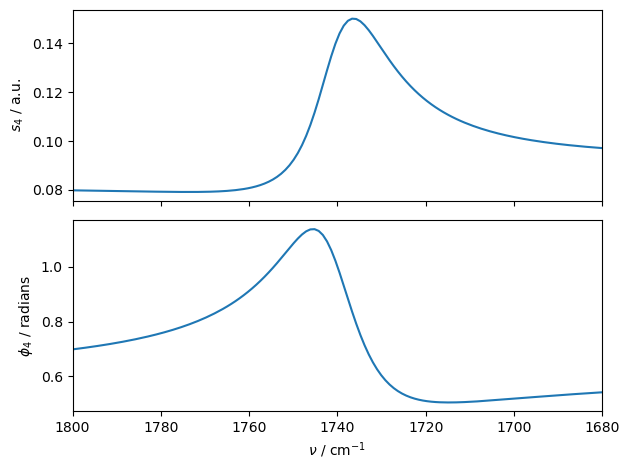

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 4
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7

# -------------------------------------------------------
# PMMA dielectric function (synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.array([30e-9])  # fixed at 30 nm

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
eps0 = 8.8541878128e-12
c0   = 299792458.0
e    = 1.602176634e-19
hbar = 1.054571817e-34

sigma0 = e**2 / (4*hbar)
t_g = 0.3e-9

omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------------------------------
# Build sample: air / graphene / PMMA / Si
# -------------------------------------------------------
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],
             t_pmma[:, np.newaxis]),
    nu_vac=nu_vac,
)

# --------------------
# Gold reference (Au)
# --------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# --------------------
# Measurement signals
# --------------------
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# -------------------------------
# Normalized complex scattering
# -------------------------------
eta_n = sigma_stack / sigma_Au

# -----------
# Plotting
# -----------
nu_per_cm = nu_vac * 1e-2

fig, axes = plt.subplots(nrows=2, sharex=True)
axes[0].plot(nu_per_cm, np.abs(eta_n[0]))
axes[1].plot(nu_per_cm, np.angle(eta_n[0]))

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
plt.show()


In [ ]:
## Fixed thickness of PMMA 30 nm (## Order 3 demodulation for Graphene)

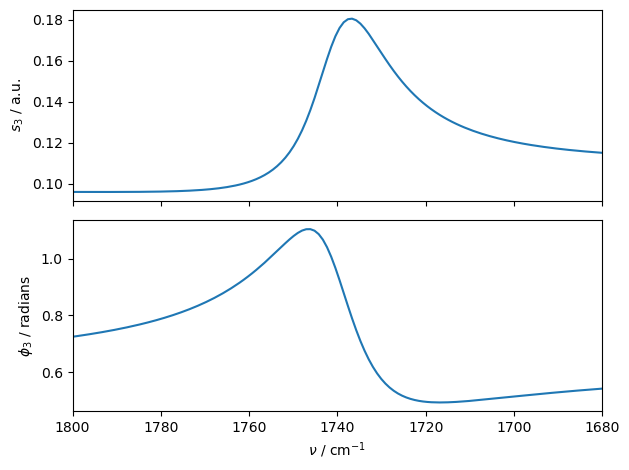

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 3
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7

# -------------------------------------------------------
# PMMA dielectric function (synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.array([30e-9])  # fixed at 30 nm

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
eps0 = 8.8541878128e-12
c0   = 299792458.0
e    = 1.602176634e-19
hbar = 1.054571817e-34

sigma0 = e**2 / (4*hbar)
t_g = 0.3e-9

omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------------------------------
# Build sample: air / graphene / PMMA / Si
# -------------------------------------------------------
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],
             t_pmma[:, np.newaxis]),
    nu_vac=nu_vac,
)

# --------------------
# Gold reference (Au)
# --------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# --------------------
# Measurement signals
# --------------------
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# -------------------------------
# Normalized complex scattering
# -------------------------------
eta_n = sigma_stack / sigma_Au

# -----------
# Plotting
# -----------
nu_per_cm = nu_vac * 1e-2

fig, axes = plt.subplots(nrows=2, sharex=True)
axes[0].plot(nu_per_cm, np.abs(eta_n[0]))
axes[1].plot(nu_per_cm, np.angle(eta_n[0]))

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
plt.show()


In [ ]:
## Fixed thickness of PMMA 30 nm (## Order 2 demodulation for Graphene)

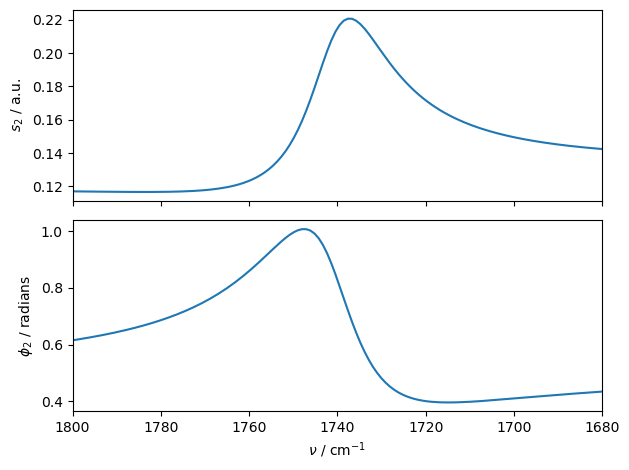

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 2
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7

# -------------------------------------------------------
# PMMA dielectric function (synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.array([30e-9])  # fixed at 30 nm

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
eps0 = 8.8541878128e-12
c0   = 299792458.0
e    = 1.602176634e-19
hbar = 1.054571817e-34

sigma0 = e**2 / (4*hbar)
t_g = 0.3e-9

omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------------------------------
# Build sample: air / graphene / PMMA / Si
# -------------------------------------------------------
sample_stack = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],
             t_pmma[:, np.newaxis]),
    nu_vac=nu_vac,
)

# --------------------
# Gold reference (Au)
# --------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# --------------------
# Measurement signals
# --------------------
alpha_eff_stack = snompy.fdm.eff_pol_n(
    sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

alpha_eff_Au = snompy.fdm.eff_pol_n(
    sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
)
r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

# -------------------------------
# Normalized complex scattering
# -------------------------------
eta_n = sigma_stack / sigma_Au

# -----------
# Plotting
# -----------
nu_per_cm = nu_vac * 1e-2

fig, axes = plt.subplots(nrows=2, sharex=True)
axes[0].plot(nu_per_cm, np.abs(eta_n[0]))
axes[1].plot(nu_per_cm, np.angle(eta_n[0]))

axes[0].set_ylabel(r"$s_{" f"{n}" r"}$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_{" f"{n}" r"}$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min()),
)
fig.tight_layout()
plt.show()


In [ ]:
## Combined code for n = 2,3,4 for graphene

Figure saved at: C:\Users\user\OneDrive\Desktop\Snompy\combined_spectra.png


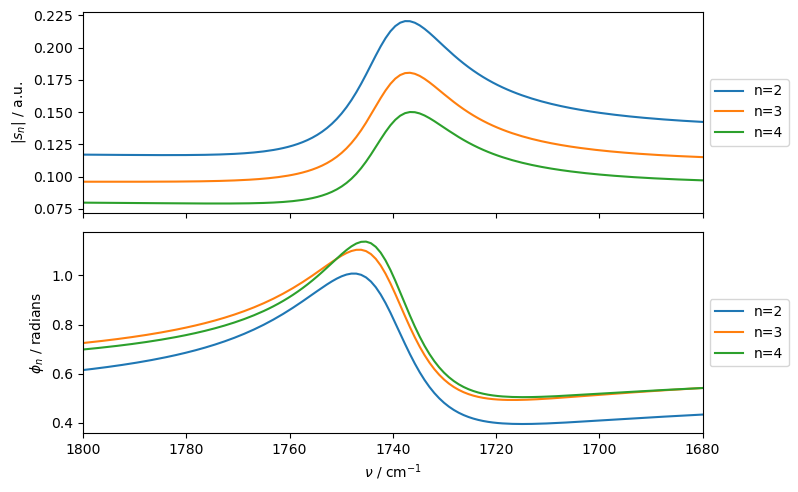

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -------------------------------
# Media: air (superstrate) & Si (substrate)
# -------------------------------
eps_air = 1.0
eps_Si = 11.7

# -------------------------------------------------------
# PMMA dielectric function (synthetic Lorentz model)
# -------------------------------------------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2.0
)
t_pmma = np.array([30e-9])  # 30 nm PMMA

# -------------------------------------------------------
# Graphene monolayer (0.3 nm) via sheet conductivity σ0
# -------------------------------------------------------
eps0 = 8.8541878128e-12
c0   = 299792458.0
e    = 1.602176634e-19
hbar = 1.054571817e-34

sigma0 = e**2 / (4*hbar)
t_g = 0.3e-9

omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

# -------------------------------
# Demodulation orders
# -------------------------------
demod_orders = [2, 3, 4]
eta_list = []

# -------------------------------
# Calculate eta_n for each n
# -------------------------------
for n in demod_orders:
    sample_stack = snompy.Sample(
        eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
        t_stack=(np.full_like(t_pmma, t_g)[:, np.newaxis],
                 t_pmma[:, np.newaxis]),
        nu_vac=nu_vac,
    )

    # Gold reference
    eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
    sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

    # Stack measurement
    alpha_eff_stack = snompy.fdm.eff_pol_n(
        sample=sample_stack, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_stack = sample_stack.refl_coef(theta_in=theta_in)
    sigma_stack = (1 + c_r * r_coef_stack) ** 2 * alpha_eff_stack

    # Gold measurement
    alpha_eff_Au = snompy.fdm.eff_pol_n(
        sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
    sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

    # Normalized scattering
    eta_n = sigma_stack / sigma_Au
    eta_list.append(eta_n)

# -------------------------------
# Plotting
# -------------------------------
nu_per_cm = nu_vac * 1e-2
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,5))

for eta, n, c in zip(eta_list, demod_orders, colors):
    axes[0].plot(nu_per_cm, np.abs(eta).flatten(), label=f"n={n}", color=c)
    axes[1].plot(nu_per_cm, np.angle(eta).flatten(), label=f"n={n}", color=c)

axes[0].set_ylabel(r"$|s_n|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_n$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min())
)

# Legend on the right
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()

# -------------------------------
# Save figure
# -------------------------------
save_path = r"C:\Users\user\OneDrive\Desktop\Snompy\combined_spectra.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved at: {save_path}")

plt.show()


In [ ]:
## Combine code of PMMA only, Si₃N₄ + PMMA, and Graphene + PMMA n = 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
n = 2
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -----------------------
# Media
# -----------------------
eps_air = 1.0
eps_Si = 11.7

# -----------------------
# PMMA
# -----------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.array([30e-9])
sample_P = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac
)

# -----------------------
# Si3N4 + PMMA
# -----------------------
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac, nu_j=900e2, gamma_j=50e2, A_j=2e8, eps_inf=4.0
)
t_Si3N4 = np.array([15e-9])
sample_Si3N4_P = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(t_Si3N4[:, np.newaxis], t_pmma[:, np.newaxis]),
    nu_vac=nu_vac
)

# -----------------------
# Graphene + PMMA
# -----------------------
eps0 = 8.8541878128e-12
c0 = 299792458.0
e = 1.602176634e-19
hbar = 1.054571817e-34

t_g = 0.3e-9
sigma0 = e**2 / (4*hbar)
omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

t_g_array = np.full_like(t_pmma, t_g)
sample_G_P = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(t_g_array[:, np.newaxis], t_pmma[:, np.newaxis]),
    nu_vac=nu_vac
)

# -----------------------
# Gold reference
# -----------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# -----------------------
# Function to compute normalized scattering
# -----------------------
def compute_eta(sample):
    alpha_eff = snompy.fdm.eff_pol_n(
        sample=sample, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef = sample.refl_coef(theta_in=theta_in)
    sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

    alpha_eff_Au = snompy.fdm.eff_pol_n(
        sample=sample_Au, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
    sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

    return sigma / sigma_Au

# -----------------------
# Compute all etas
# -----------------------
eta_list = [
    compute_eta(sample_P),
    compute_eta(sample_Si3N4_P),
    compute_eta(sample_G_P)
]

labels = [
    f"PMMA {t_pmma[0]*1e9:.0f} nm",
    f"Si3N4 {t_Si3N4[0]*1e9:.0f} nm + PMMA {t_pmma[0]*1e9:.0f} nm",
    f"Graphene {t_g*1e9:.1f} nm + PMMA {t_pmma[0]*1e9:.0f} nm"
]

colors = ['tab:blue', 'tab:orange', 'tab:green']
nu_per_cm = nu_vac * 1e-2

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,5))

for eta, label, c in zip(eta_list, labels, colors):
    axes[0].plot(nu_per_cm, np.abs(eta[0]), label=label, color=c)
    axes[1].plot(nu_per_cm, np.angle(eta[0]), label=label, color=c)

axes[0].set_ylabel(r"$|s_2|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi_2$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min())
)

axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))  # legend on the right
fig.tight_layout()

# -----------------------
# Save the figure
# -----------------------
fig.savefig(r"C:\Users\user\OneDrive\Desktop\Snompy\snom_spectra.png", dpi=300, bbox_inches='tight')

plt.show()


ModuleNotFoundError: No module named 'snompy'

In [ ]:
## Combine code of PMMA only, Si₃N₄ + PMMA, and Graphene + PMMA n = 3

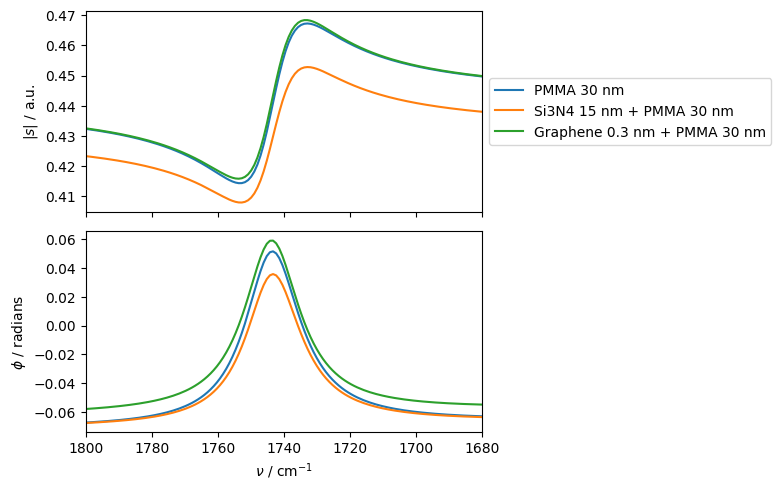

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 200e-9
L_tip = 350e-9
n_list = [2, 2, 2]  # harmonics for each sample
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -----------------------
# Media
# -----------------------
eps_air = 1.0
eps_Si = 11.7

# -----------------------
# PMMA
# -----------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.array([30e-9])  # 1D array

sample_P = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac
)

# -----------------------
# Si3N4 + PMMA
# -----------------------
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac, nu_j=900e2, gamma_j=50e2, A_j=2e8, eps_inf=4.0
)
t_Si3N4 = np.array([15e-9])

sample_Si3N4_P = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(t_Si3N4[:, np.newaxis], t_pmma[:, np.newaxis]),
    nu_vac=nu_vac
)

# -----------------------
# Graphene + PMMA
# -----------------------
eps0 = 8.8541878128e-12
c0 = 299792458.0
e = 1.602176634e-19
hbar = 1.054571817e-34

t_g = 0.3e-9
sigma0 = e**2 / (4*hbar)
omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)

t_g_array = np.full_like(t_pmma, t_g)
sample_G_P = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(t_g_array[:, np.newaxis], t_pmma[:, np.newaxis]),
    nu_vac=nu_vac
)

# -----------------------
# Gold reference
# -----------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# -----------------------
# Function to compute normalized scattering
# -----------------------
def compute_eta(sample):
    alpha_eff = snompy.fdm.eff_pol_n(
        sample=sample, A_tip=A_tip, n=n_list[0], r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef = sample.refl_coef(theta_in=theta_in)
    sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

    alpha_eff_Au = snompy.fdm.eff_pol_n(
        sample=sample_Au, A_tip=A_tip, n=n_list[0], r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
    sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

    return sigma / sigma_Au

# -----------------------
# Compute etas for all samples
# -----------------------
eta_list = [
    compute_eta(sample_P),
    compute_eta(sample_Si3N4_P),
    compute_eta(sample_G_P)
]

labels = [
    f"PMMA {t_pmma[0]*1e9:.0f} nm",
    f"Si3N4 {t_Si3N4[0]*1e9:.0f} nm + PMMA {t_pmma[0]*1e9:.0f} nm",
    f"Graphene {t_g*1e9:.1f} nm + PMMA {t_pmma[0]*1e9:.0f} nm"
]

colors = ['tab:blue', 'tab:orange', 'tab:green']
nu_per_cm = nu_vac * 1e-2

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,5))

for eta, label, c in zip(eta_list, labels, colors):
    axes[0].plot(nu_per_cm, np.abs(eta[0]), label=label, color=c)
    axes[1].plot(nu_per_cm, np.angle(eta[0]), label=label, color=c)

axes[0].set_ylabel(r"$|s|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min())
)

axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

# -----------------------
# Save figure
# -----------------------
#fig.savefig(r"C:\Users\user\OneDrive\Desktop\Snompy\snom_combined.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
## Combine code of PMMA only, Si₃N₄ + PMMA, and Graphene + PMMA n = 4

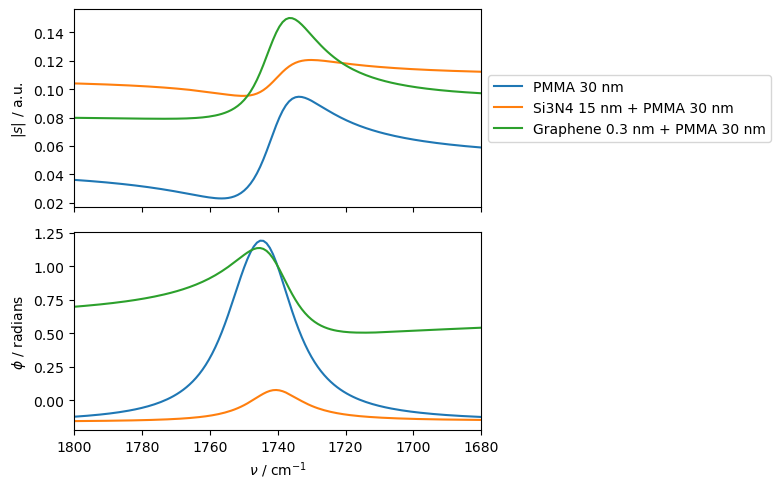

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import snompy

# -----------------------
# Experimental parameters
# -----------------------
A_tip = 20e-9
r_tip = 30e-9
L_tip = 350e-9
theta_in = np.deg2rad(60)
c_r = 0.3
nu_vac = np.linspace(1680, 1800, 128) * 1e2  # [m^-1]
method = "Q_ave"

# -----------------------
# Media constants
# -----------------------
eps_air = 1.0
eps_Si = 11.7

# -----------------------
# PMMA (30 nm)
# -----------------------
eps_pmma = snompy.sample.lorentz_perm(
    nu_vac, nu_j=1738e2, gamma_j=20e2, A_j=4.2e8, eps_inf=2
)
t_pmma = np.array([30e-9])

sample_P = snompy.Sample(
    eps_stack=(eps_air, eps_pmma, eps_Si),
    t_stack=(t_pmma[:, np.newaxis],),
    nu_vac=nu_vac
)

# -----------------------
# Si3N4 (15 nm) + PMMA
# -----------------------
eps_Si3N4 = snompy.sample.lorentz_perm(
    nu_vac, nu_j=900e2, gamma_j=50e2, A_j=2e8, eps_inf=4.0
)
t_Si3N4 = np.array([15e-9])

sample_Si3N4_P = snompy.Sample(
    eps_stack=(eps_air, eps_Si3N4, eps_pmma, eps_Si),
    t_stack=(t_Si3N4[:, np.newaxis], t_pmma[:, np.newaxis]),
    nu_vac=nu_vac
)

# -----------------------
# Graphene (0.3 nm) + PMMA
# -----------------------
eps0 = 8.8541878128e-12
c0 = 299792458.0
e = 1.602176634e-19
hbar = 1.054571817e-34

t_g = 0.3e-9
sigma0 = e**2 / (4*hbar)
omega = 2*np.pi * c0 * nu_vac
eps_graphene = 1.0 + 1j * sigma0 / (eps0 * omega * t_g)
t_g_array = np.full_like(t_pmma, t_g)

sample_G_P = snompy.Sample(
    eps_stack=(eps_air, eps_graphene, eps_pmma, eps_Si),
    t_stack=(t_g_array[:, np.newaxis], t_pmma[:, np.newaxis]),
    nu_vac=nu_vac
)

# -----------------------
# Gold reference
# -----------------------
eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)

# -----------------------
# Function to compute normalized scattering
# -----------------------
def compute_eta(sample, n_harm):
    alpha_eff = snompy.fdm.eff_pol_n(
        sample=sample, A_tip=A_tip, n=n_harm, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef = sample.refl_coef(theta_in=theta_in)
    sigma = (1 + c_r * r_coef) ** 2 * alpha_eff

    alpha_eff_Au = snompy.fdm.eff_pol_n(
        sample=sample_Au, A_tip=A_tip, n=n_harm, r_tip=r_tip, L_tip=L_tip, method=method
    )
    r_coef_Au = sample_Au.refl_coef(theta_in=theta_in)
    sigma_Au = (1 + c_r * r_coef_Au) ** 2 * alpha_eff_Au

    return sigma / sigma_Au

# -----------------------
# Compute etas
# -----------------------
eta_list = [
    compute_eta(sample_P, n_harm=4),
    compute_eta(sample_Si3N4_P, n_harm=4),
    compute_eta(sample_G_P, n_harm=4)
]

labels = [
    f"PMMA {t_pmma[0]*1e9:.0f} nm",
    f"Si3N4 {t_Si3N4[0]*1e9:.0f} nm + PMMA {t_pmma[0]*1e9:.0f} nm",
    f"Graphene {t_g*1e9:.1f} nm + PMMA {t_pmma[0]*1e9:.0f} nm"
]

colors = ['tab:blue', 'tab:orange', 'tab:green']
nu_per_cm = nu_vac * 1e-2

# -----------------------
# Plotting
# -----------------------
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,5))

for eta, label, c in zip(eta_list, labels, colors):
    axes[0].plot(nu_per_cm, np.abs(eta[0]), label=label, color=c)
    axes[1].plot(nu_per_cm, np.angle(eta[0]), label=label, color=c)

axes[0].set_ylabel(r"$|s|$ / a.u.")
axes[1].set(
    xlabel=r"$\nu$ / cm$^{-1}$",
    ylabel=r"$\phi$ / radians",
    xlim=(nu_per_cm.max(), nu_per_cm.min())
)

axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

# -----------------------
# Save figure
# -----------------------
fig.savefig(r"C:\Users\user\OneDrive\Desktop\Snompy\snom_combined_n4.png", dpi=300, bbox_inches='tight')

plt.show()
